# SpliceAI2

![SpliceAI2](https://proto-bio.github.io/proto-assets/images/tool/spliceai2/hero.png)

SpliceAI2 is Illumina's successor to SpliceAI. From primary DNA sequence it predicts per-position splice donor and acceptor usage, the usage of splice junctions between candidate sites, and full transcripts decoded as the highest-scoring paths through the resulting splice graph. Its variant mode compares reference and alternate alleles read from a reference genome and reports the strongest donor, acceptor, and junction gains and losses around each variant. The model is conditioned on a species channel, so one network covers human and nine other mammalian assemblies.

This notebook demonstrates both registered tools: `run_spliceai2_predict` for splice sites, junctions, and transcripts on a DNA sequence, and `run_spliceai2_score` for variant splice effects on GRCh38.

- Repository: [Illumina/SpliceAI2](https://github.com/Illumina/SpliceAI2)
- Weights: [illumina-ai/SpliceAI2](https://huggingface.co/illumina-ai/SpliceAI2)
- Manuscript: [A unified framework for quantitative splicing and transcript prediction](https://assets.illumina.com/content/dam/illumina-marketing/images/genomics-research/articles/spliceai2/SpliceAI2.pdf)

**Gated weights.** Accept the model terms at [huggingface.co/illumina-ai/SpliceAI2](https://huggingface.co/illumina-ai/SpliceAI2), then set `HF_TOKEN` to a token for that account before running. The weights are released for non-commercial use only. SpliceAI2 requires a GPU.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyfaidx

from proto_tools.tools.rna_splicing.spliceai2 import (
    SpliceAI2PredictConfig,
    SpliceAI2PredictInput,
    SpliceAI2ScoreConfig,
    SpliceAI2ScoreInput,
    SpliceAI2Variant,
    run_spliceai2_predict,
    run_spliceai2_score,
)
from proto_tools.utils.notebook_docs import display_api_reference, display_available_tools

display_available_tools("spliceai2")

- **`run_spliceai2_predict()`** — Predict splice site and junction usage and decode transcripts from DNA with SpliceAI2
- **`run_spliceai2_score()`** — Score variants for changes in splice site and junction usage with SpliceAI2

## Splice site, junction, and transcript prediction

`run_spliceai2_predict` takes sense-strand DNA of any length. The model pads 65,536 bp of unknown bases on each side internally, so every input position gets a donor probability (scored at the first base of an intron) and an acceptor probability (scored at the last base of an intron). Sites above 0.01 usage become candidates for junction prediction, and the top `num_transcripts` paths through the splice graph are returned as exon lists.

In [2]:
# API reference for the prediction tool
display_api_reference("spliceai2-predict", "input", "run_spliceai2_predict")
display_api_reference("spliceai2-predict", "config", "run_spliceai2_predict")
display_api_reference("spliceai2-predict", "output", "run_spliceai2_predict")

**Input** — `SpliceAI2PredictInput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequences</code> | <code>list[str]</code> | required | Sense-strand DNA sequence(s) to predict splice sites and transcripts for |

**Config** — `SpliceAI2PredictConfig`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>device</code> | <code>str</code> | <code>'cuda'</code> | Device to run the model on (e.g. 'cuda', 'cuda:0') |
| <code>assembly</code> | <code>Literal['GRCh38', 'NHGRI_mPanTro3-v2.0', 'Panubis1.0', 'T2T-MFA8v1.1', 'Mmul_10', 'ARS-UCD2.0', 'ARS-UI_Ramb_v3.0', 'Sscrofa11.1', 'GRCm38', 'GRCr8']</code> | <code>'GRCh38'</code> | Species assembly conditioning the model (GRCh38 for any human sequence) |
| <code>num_transcripts</code> | <code>int</code> | <code>3</code> | Number of highest-scoring transcripts to decode per sequence |

**Output** — `SpliceAI2PredictOutput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>results</code> | <code>list[SpliceAI2Prediction]</code> | required | Splice site, junction, and transcript predictions, one per input sequence |

**`SpliceAI2Prediction`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>donor_probabilities</code> | <code>list[float]</code> | required | Per-position splice donor usage (0-1) |
| <code>acceptor_probabilities</code> | <code>list[float]</code> | required | Per-position splice acceptor usage (0-1) |
| <code>junctions</code> | <code>list[SpliceAI2Junction]</code> | required | Junctions with usage >= 0.01 between candidate splice sites |
| <code>transcripts</code> | <code>list[SpliceAI2Transcript]</code> | required | Highest-scoring decoded transcripts, best first |

**`SpliceAI2Junction`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>donor</code> | <code>int</code> | required | 1-based position of the intron's first base (donor site) |
| <code>acceptor</code> | <code>int</code> | required | 1-based position of the intron's last base (acceptor site) |
| <code>probability</code> | <code>float</code> | required | Predicted junction usage (0-1) |

**`SpliceAI2Transcript`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>exons</code> | <code>list[tuple[int, int]]</code> | required | Exons as 1-based inclusive (start, end) intervals, in order |

### Fetch the HBB locus from GRCh38

HBB (hemoglobin beta) is a compact three-exon gene on the minus strand of chromosome 11 (GRCh38 gene span roughly 11:5,225,464-5,227,071). Naming the `grch38` assembly provisions the Ensembl primary assembly on first use; its chromosomes are named without a `chr` prefix. The gene plus 1 kb of flank on each side is read and reverse-complemented to the sense strand, the orientation `run_spliceai2_predict` expects.

In [3]:
# Resolve the provisioned GRCh38 FASTA (downloaded on first use)
fasta_path = SpliceAI2ScoreConfig(reference_fasta="grch38").require_reference_fasta("spliceai2")
genome = pyfaidx.Fasta(str(fasta_path))

# HBB gene span plus 1 kb of flank (1-based, inclusive)
CHROM, GENE_START, GENE_END, FLANK = "11", 5_225_464, 5_227_071, 1_000
window = genome[CHROM][GENE_START - FLANK - 1 : GENE_END + FLANK]

# HBB is on the minus strand, so reverse-complement to the sense strand
hbb_sense = (-window).seq.upper()
WINDOW_END = window.end


def to_genomic(sense_position: int) -> int:
    """Map a 1-based sense-strand position in the window to a GRCh38 coordinate."""
    return WINDOW_END - sense_position + 1


print(f"Window {CHROM}:{window.start}-{window.end} ({len(hbb_sense):,} bp, sense strand)")
print(hbb_sense[:60])

Window 11:5224464-5228071 (3,608 bp, sense strand)
GGAACTTGAATCAAGGAAATGATTTTAAAACGCAGTATTCTTAGTGGACTAGAGGAAAAA


In [4]:
# Predict splice sites, junctions, and the top 3 transcripts (the default)
predict_result = run_spliceai2_predict(
    SpliceAI2PredictInput(sequences=[hbb_sense]),
    SpliceAI2PredictConfig(device="cuda"),
)
assert predict_result.success, predict_result.errors
prediction = predict_result.results[0]
print(f"Positions scored: {len(prediction.donor_probabilities):,}")
print(f"Junctions (usage >= 0.01): {len(prediction.junctions)}")
print(f"Transcripts decoded: {len(prediction.transcripts)}")

Running run_spliceai2_predict [00:00]

Positions scored: 3,608
Junctions (usage >= 0.01): 21
Transcripts decoded: 3


HBB has two introns, so the strongest peaks should be two donors and two acceptors. The table lists every position with usage above 0.5, with both its 1-based window position and its GRCh38 coordinate.

In [5]:
# Collect donor and acceptor peaks with usage > 0.5
peaks = pd.DataFrame(
    [
        {"site": site, "window_position": i, "grch38_position": to_genomic(i), "probability": round(p, 3)}
        for site, probs in [("donor", prediction.donor_probabilities), ("acceptor", prediction.acceptor_probabilities)]
        for i, p in enumerate(probs, start=1)
        if p > 0.5
    ]
)
peaks.sort_values("window_position", ignore_index=True)

,site,window_position,grch38_position,probability
0,donor,1143,5226929,0.870
1,acceptor,1272,5226800,0.892
2,donor,1496,5226576,0.935
3,acceptor,2345,5225727,0.950


In [6]:
# Junctions as introns between a donor and an acceptor, strongest first
junctions = pd.DataFrame([j.model_dump() for j in prediction.junctions])
junctions["intron_length"] = junctions["acceptor"] - junctions["donor"] + 1
junctions.sort_values("probability", ascending=False, ignore_index=True).head(10)

,donor,acceptor,probability,intron_length
0,1496,2345,0.916431,850
1,1143,1272,0.749351,130
2,561,1032,0.130169,472
3,1127,1272,0.056244,146
4,536,1032,0.051394,497
5,872,1032,0.047150,161
6,1496,2074,0.045354,579
7,561,1272,0.037754,712
8,2201,2345,0.030734,145
9,1105,1272,0.030196,168


In [7]:
# Exons of the best-scoring transcript, in window and GRCh38 coordinates
top_transcript = prediction.transcripts[0]
pd.DataFrame(
    [
        {
            "exon": n,
            "window_start": start,
            "window_end": end,
            "grch38_start": to_genomic(end),
            "grch38_end": to_genomic(start),
            "length": end - start + 1,
        }
        for n, (start, end) in enumerate(top_transcript.exons, start=1)
    ]
)

,exon,window_start,window_end,grch38_start,grch38_end,length
0,1,1,1142,5226930,5228071,1142
1,2,1273,1495,5226577,5226799,223
2,3,2346,3608,5224464,5225726,1263


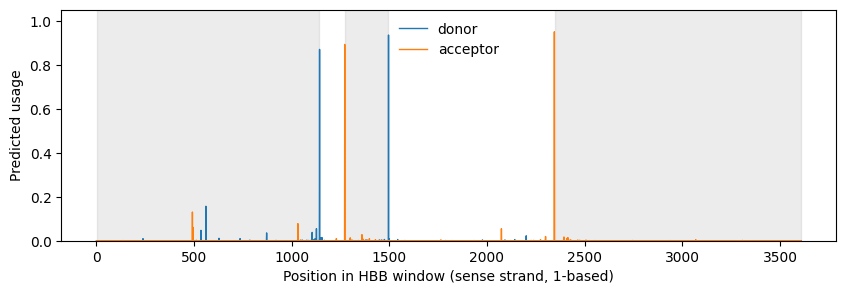

In [8]:
# Plot donor and acceptor usage along the sense strand, shading the top transcript's exons
fig, ax = plt.subplots(figsize=(10, 3))
positions = range(1, len(hbb_sense) + 1)
ax.plot(positions, prediction.donor_probabilities, label="donor", linewidth=1)
ax.plot(positions, prediction.acceptor_probabilities, label="acceptor", linewidth=1)
for start, end in top_transcript.exons:
    ax.axvspan(start, end, color="grey", alpha=0.15)
ax.set_xlabel("Position in HBB window (sense strand, 1-based)")
ax.set_ylabel("Predicted usage")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False)
plt.show()

## Variant splice-effect scoring

`run_spliceai2_score` reads a 196,608 bp window around each variant from the reference genome, applies the alternate allele, and compares the two alleles on the gene strand you supply. For each variant it reports the ten strongest donor, acceptor, and junction gains and losses within 32,768 bp, plus a `summary_score`: the largest donor or acceptor delta. Upstream suggests 0.1, 0.25, and 0.5 as increasingly stringent summary-score thresholds.

In [9]:
# API reference for the variant-scoring tool
display_api_reference("spliceai2-score", "input", "run_spliceai2_score")
display_api_reference("spliceai2-score", "config", "run_spliceai2_score")
display_api_reference("spliceai2-score", "output", "run_spliceai2_score")

**Input** — `SpliceAI2ScoreInput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>variants</code> | <code>list[SpliceAI2Variant]</code> | required | Variants (with gene strand) to score for splice-altering effects |

**Config** — `SpliceAI2ScoreConfig`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>device</code> | <code>str</code> | <code>'cuda'</code> | Device to run the model on (e.g. 'cuda', 'cuda:0') |
| <code>reference_fasta</code> | <code>Union[Literal['grch37', 'grch38'], str, NoneType]</code> | <code>None</code> | Assembly name ('grch38'/'grch37', provisioned on demand) or a local FASTA path |
| <code>assembly</code> | <code>Literal['GRCh38', 'NHGRI_mPanTro3-v2.0', 'Panubis1.0', 'T2T-MFA8v1.1', 'Mmul_10', 'ARS-UCD2.0', 'ARS-UI_Ramb_v3.0', 'Sscrofa11.1', 'GRCm38', 'GRCr8']</code> | <code>'GRCh38'</code> | Species assembly conditioning the model (GRCh38 for any human sequence) |

**Output** — `SpliceAI2ScoreOutput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>results</code> | <code>list[SpliceAI2VariantResult]</code> | required | Per-variant SpliceAI2 predictions (1:1 with input variants) |

**`SpliceAI2VariantResult`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>chromosome</code> | <code>str</code> | required | Variant chromosome |
| <code>position</code> | <code>int</code> | required | Variant position (1-based) |
| <code>ref</code> | <code>str</code> | required | Reference allele |
| <code>alt</code> | <code>str</code> | required | Alternate allele |
| <code>strand</code> | <code>Literal['+', '-']</code> | required | Gene strand the variant was scored against |
| <code>donor_gain</code> | <code>list[SpliceAI2SiteChange]</code> | required | Strongest donor gains, largest first |
| <code>donor_loss</code> | <code>list[SpliceAI2SiteChange]</code> | required | Strongest donor losses, largest first |
| <code>acceptor_gain</code> | <code>list[SpliceAI2SiteChange]</code> | required | Strongest acceptor gains, largest first |
| <code>acceptor_loss</code> | <code>list[SpliceAI2SiteChange]</code> | required | Strongest acceptor losses, largest first |
| <code>junction_gain</code> | <code>list[SpliceAI2JunctionChange]</code> | required | Strongest junction gains, largest first |
| <code>junction_loss</code> | <code>list[SpliceAI2JunctionChange]</code> | required | Strongest junction losses, largest first |
| <code>metrics</code> | <code>SpliceAI2ScoreMetrics</code> | required | Per-variant summary score |

**`SpliceAI2SiteChange`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>delta_score</code> | <code>float</code> | required | Absolute change in splice site usage (0-1) |
| <code>ref_score</code> | <code>float</code> | required | Splice site usage with the reference allele |
| <code>alt_score</code> | <code>float</code> | required | Splice site usage with the alternate allele |
| <code>distance</code> | <code>int</code> | required | Signed genomic distance (bp) from variant to site; positive = higher coordinate |

**`SpliceAI2JunctionChange`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>delta_score</code> | <code>float</code> | required | Absolute change in junction usage (0-1) |
| <code>ref_score</code> | <code>float</code> | required | Junction usage with the reference allele |
| <code>alt_score</code> | <code>float</code> | required | Junction usage with the alternate allele |
| <code>donor_distance</code> | <code>int</code> | required | Signed genomic distance (bp) from variant to donor; positive = higher coordinate |
| <code>acceptor_distance</code> | <code>int</code> | required | Signed genomic distance (bp) from variant to acceptor; positive = higher coordinate |

**Metrics** — `SpliceAI2ScoreMetrics` (one set per `results` item)

| Metric | Type | Range | Unit | Description |
|--------|------|-------|------|-------------|
| <code>summary_score</code> **(primary)** | <code>float</code> | <code>[0, 1]</code> |  | Maximum delta score across donor/acceptor gain and loss |

Two classic beta-thalassemia variants in HBB intron 1, given in GRCh38 forward-strand alleles (HBB is on the minus strand, so a coding G>A is a genomic C>T):

- **IVS1-1 G>A** (`HBB:c.92+1G>A`): destroys the invariant GT of the intron-1 donor; expected to show a strong donor loss.
- **IVS1-110 G>A** (`HBB:c.93-21G>A`): creates a new AG inside intron 1; expected to show a cryptic acceptor gain about 20 bp upstream of the normal intron-1 acceptor.

In [10]:
# The two HBB intron-1 variants, scored against the minus-strand gene
hbb_variants = {
    "IVS1-1 G>A": SpliceAI2Variant(chromosome="11", position=5226929, ref="C", alt="T", strand="-"),
    "IVS1-110 G>A": SpliceAI2Variant(chromosome="11", position=5226820, ref="C", alt="T", strand="-"),
}

score_result = run_spliceai2_score(
    SpliceAI2ScoreInput(variants=list(hbb_variants.values())),
    SpliceAI2ScoreConfig(reference_fasta="grch38", device="cuda"),
)
assert score_result.success, score_result.errors

Running run_spliceai2_score [00:00]

In [11]:
# Summary score per variant, binned against the 0.1 / 0.25 / 0.5 thresholds
def tier(score: float) -> str:
    """Name the strictest threshold a summary score passes."""
    return next((f">= {t}" for t in (0.5, 0.25, 0.1) if score >= t), "< 0.1")


pd.DataFrame(
    [
        {
            "variant": name,
            "position": r.position,
            "summary_score": round(r.summary_score, 3),
            "tier": tier(r.summary_score),
        }
        for name, r in zip(hbb_variants, score_result.results, strict=True)
    ]
)

,variant,position,summary_score,tier
0,IVS1-1 G>A,5226929,0.873,>= 0.5
1,IVS1-110 G>A,5226820,0.664,>= 0.5


Each effect list is sorted largest first, so its first entry is the strongest change of that type. `distance` is the signed offset in bp (along the gene) from the variant to the affected site; junction changes report the offsets of both ends.

In [12]:
# Strongest change per effect type for each variant
SITE_EFFECTS = ["donor_gain", "donor_loss", "acceptor_gain", "acceptor_loss"]
JUNCTION_EFFECTS = ["junction_gain", "junction_loss"]

rows = []
for name, r in zip(hbb_variants, score_result.results, strict=True):
    for effect in SITE_EFFECTS:
        top = getattr(r, effect)[0]
        rows.append(
            {
                "variant": name,
                "effect": effect,
                "delta": top.delta_score,
                "ref": top.ref_score,
                "alt": top.alt_score,
                "distance": f"{top.distance:+d}",
            }
        )
    for effect in JUNCTION_EFFECTS:
        top = getattr(r, effect)[0]
        rows.append(
            {
                "variant": name,
                "effect": effect,
                "delta": top.delta_score,
                "ref": top.ref_score,
                "alt": top.alt_score,
                "distance": f"{top.donor_distance:+d} / {top.acceptor_distance:+d}",
            }
        )

pd.DataFrame(rows).round(3).pivot(index="effect", columns="variant", values=["delta", "distance"])

delta                 distance             
variant       IVS1-1 G>A IVS1-110 G>A  IVS1-1 G>A IVS1-110 G>A
effect                                                        
acceptor_gain      0.018        0.664      +16400           -1
acceptor_loss      0.043        0.296        -129          -20
donor_gain         0.644        0.031         +16       +16285
donor_loss         0.873        0.002          +0          +97
junction_gain      0.432        0.531  +16 / -129    +109 / -1
junction_loss      0.728        0.181   +0 / -129   +109 / -20

**Interpretation.** IVS1-1 should clear the 0.5 threshold through `donor_loss` at distance 0: the variant sits on the first intron base, exactly where the lost donor is scored, and the matching `junction_loss` is the intron-1 junction. IVS1-110 should be driven by `acceptor_gain` near the variant, roughly 20 bp upstream of the normal acceptor, with a smaller `acceptor_loss` at the normal acceptor as usage shifts to the cryptic site. Scores between 0.1 and 0.25 are best read as weak evidence; above 0.5 the prediction is high confidence.

### Reproducing the manuscript's RNA-validated patient variants

The SpliceAI2 manuscript (Jaganathan et al. 2026, Fig. 4h,i) highlights two rare variants found in unresolved Genomics England rare disease probands, each confirmed by the patient's blood RNA-seq:

- **PKD1** `chr16:2,115,031 A>T` (cystic kidney disease): activates a cryptic donor, used in 32.3% of the patient's reads versus 0.3% in controls. Reported as a donor gain with SpliceAI2 score 0.34.
- **PEX1** `chr7:92,509,423 A>C` (rod-cone dystrophy): weakens an existing donor, cutting usage of its junction from 60.9% in controls to 35.3%. Reported as a donor loss with SpliceAI2 score 0.35.

Both genes are on the minus strand, and the alleles are given on the GRCh38 forward strand.

In [13]:
# The two RNA-validated variants from the manuscript, with the effect and score it reports
paper_variants = {
    "PKD1 A>T": (SpliceAI2Variant(chromosome="16", position=2115031, ref="A", alt="T", strand="-"), "donor_gain", 0.34),
    "PEX1 A>C": (SpliceAI2Variant(chromosome="7", position=92509423, ref="A", alt="C", strand="-"), "donor_loss", 0.35),
}

paper_result = run_spliceai2_score(
    SpliceAI2ScoreInput(variants=[variant for variant, _, _ in paper_variants.values()]),
    SpliceAI2ScoreConfig(reference_fasta="grch38", device="cuda"),
)
assert paper_result.success, paper_result.errors

# Compare the reported effect's delta score, then show the summary score and its driving effect
rows = []
for (name, (_, effect, reported)), r in zip(paper_variants.items(), paper_result.results, strict=True):
    strongest = max(SITE_EFFECTS, key=lambda e: getattr(r, e)[0].delta_score)
    rows.append(
        {
            "variant": name,
            "reported_effect": effect,
            "reported_score": reported,
            "predicted_delta": round(getattr(r, effect)[0].delta_score, 3),
            "distance": getattr(r, effect)[0].distance,
            "summary_score": round(r.summary_score, 3),
            "summary_driver": strongest,
        }
    )
pd.DataFrame(rows)

Running run_spliceai2_score [00:00]

,variant,reported_effect,reported_score,predicted_delta,distance,summary_score,summary_driver
0,PKD1 A>T,donor_gain,0.34,0.343,3,0.343,donor_gain
1,PEX1 A>C,donor_loss,0.35,0.347,-95,0.404,acceptor_loss


**Interpretation.** Both reported effects are reproduced: the PKD1 donor gain scores 0.34 a few bases from the variant, and the PEX1 donor loss scores 0.35. For PKD1 that effect is also the summary score. For PEX1 the summary score is slightly higher (0.40) because the model also predicts loss of a nearby acceptor; the manuscript labels the variant by the donor loss that RNA-seq confirmed. Both variants pass the 0.25 threshold the manuscript used to prioritize them, though neither reaches 0.5, which is typical of partial, quantitative splicing changes like these.

## Advanced usage

### Decoding more transcripts

`num_transcripts` sets how many of the highest-scoring paths through the splice graph are decoded per sequence. Alternatives beyond the first usually differ by a weak or skipped site.

In [14]:
# Decode the five best transcripts for the HBB window
five_result = run_spliceai2_predict(
    SpliceAI2PredictInput(sequences=[hbb_sense]),
    SpliceAI2PredictConfig(num_transcripts=5, device="cuda"),
)
assert five_result.success, five_result.errors
for rank, transcript in enumerate(five_result.results[0].transcripts, start=1):
    print(f"Transcript {rank}: {len(transcript.exons)} exons {transcript.exons}")

Running run_spliceai2_predict [00:00]

Transcript 1: 3 exons [(1, 1142), (1273, 1495), (2346, 3608)]
Transcript 2: 2 exons [(1, 1495), (2346, 3608)]
Transcript 3: 4 exons [(1, 560), (1033, 1142), (1273, 1495), (2346, 3608)]
Transcript 4: 3 exons [(1, 560), (1273, 1495), (2346, 3608)]
Transcript 5: 2 exons [(1, 1142), (1273, 3608)]


### Scoring a variant when the gene strand is unknown

Variant scoring needs the strand of the affected gene. When it is unknown, score both strands and keep the larger summary score; the strand that wins is usually the one carrying the gene.

In [15]:
# Score IVS1-1 on both strands and keep the larger summary score
base = hbb_variants["IVS1-1 G>A"]
both = run_spliceai2_score(
    SpliceAI2ScoreInput(variants=[base.model_copy(update={"strand": s}) for s in ("+", "-")]),
    SpliceAI2ScoreConfig(reference_fasta="grch38", device="cuda"),
)
assert both.success, both.errors
for r in both.results:
    print(f"strand {r.strand}: summary_score = {r.summary_score:.3f}")
best = max(both.results, key=lambda r: r.summary_score)
print(f"Max over strands: {best.summary_score:.3f} (strand {best.strand})")

Running run_spliceai2_score [00:00]

strand +: summary_score = 0.000
strand -: summary_score = 0.873
Max over strands: 0.873 (strand -)


## Export

Exports are written to `example_output/` next to this notebook. Variant scores support JSON (the full nested result) and TSV (one row per variant, with the same columns as upstream's `.spliceai2` file). Predictions support JSON and NumPy (`npy`, one `[donor, acceptor]` array per sequence).

In [16]:
# Write variant scores (JSON and TSV) and predictions (JSON)
output_dir = Path("./example_output")
output_dir.mkdir(exist_ok=True)

score_result.export(name="spliceai2_scores", export_path=output_dir, file_format="json")
score_result.export(name="spliceai2_scores", export_path=output_dir, file_format="tsv")
predict_result.export(name="spliceai2_predictions", export_path=output_dir, file_format="json")
print("Written files:", sorted(path.name for path in output_dir.iterdir()))

Written files: ['spliceai2_predictions.json', 'spliceai2_scores.json', 'spliceai2_scores.tsv']
